# One sample analysis

## 🧬 Overview
### In this analysis, I’ve used one of the Squidpy demo samples, so you can easily grab the same one and give it a try yourself! 🧠✨

In [1]:
import os
import numpy as np
import scanpy as sc
import pandas as pd
import squidpy as sq
import spatools as st
import matplotlib as mpl
import matplotlib.pyplot as plt

/mnt/SATA/spatialCourse/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = sq.datasets.visium_hne_adata()

INFO     Downloading visium_hne_adata.h5ad from                                                                    
         https://exampledata.scverse.org/squidpy/figshare/visium_hne_adata.h5ad                                    


100%|████████████████████████████████████████| 329M/329M [00:00<00:00, 645GB/s]


In [3]:
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

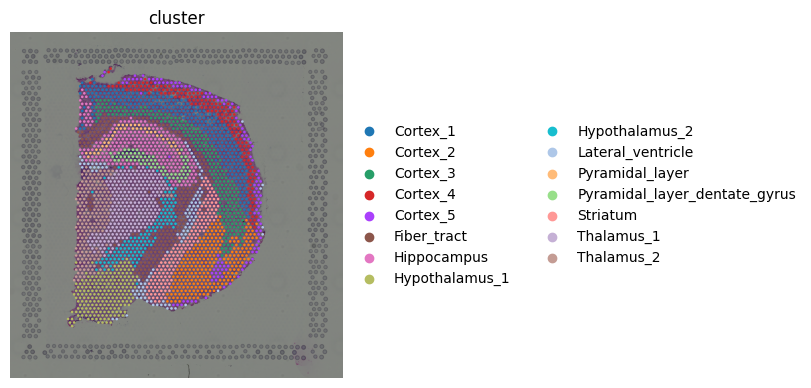

In [4]:
import matplotlib.pyplot as plt

sq.pl.spatial_scatter(adata, color="cluster", frameon=False, figsize=(8,8))# type: ignore

In [5]:
adata.obs["cluster"]

AAACAAGTATCTCCCA-1             Cortex_2
AAACAATCTACTAGCA-1             Cortex_5
AAACACCAATAACTGC-1           Thalamus_2
AAACAGAGCGACTCCT-1             Cortex_5
AAACCGGGTAGGTACC-1           Thalamus_2
                            ...        
TTGTTGTGTGTCAAGA-1    Lateral_ventricle
TTGTTTCACATCCAGG-1       Hypothalamus_1
TTGTTTCATTAGTCTA-1       Hypothalamus_1
TTGTTTCCATACAACT-1           Thalamus_2
TTGTTTGTGTAAATTC-1             Cortex_4
Name: cluster, Length: 2688, dtype: category
Categories (15, object): ['Cortex_1', 'Cortex_2', 'Cortex_3', 'Cortex_4', ..., 'Pyramidal_layer_dentate_gyrus', 'Striatum', 'Thalamus_1', 'Thalamus_2']

In [6]:
adata = st.tl.correlate_distances(adata, is_concatenated=False, cluster_col="cluster")

In [7]:
type(adata.obsm["spatial"])

numpy.ndarray

In [8]:
adata.obsm["spatial"]

array([[8230, 7237],
       [4170, 1611],
       [2519, 8315],
       ...,
       [3276, 8435],
       [3069, 6639],
       [4720, 2090]], shape=(2688, 2))

In [9]:
adata.uns["spatools"]

,x,y,point_name,color,x_neigh,y_neigh,color_neigh,distance,combination
0,8230,7237,8230_7237,Cortex_2,8367,7237,Cortex_5,137.000000,"(Cortex_2, Cortex_5)"
1,8230,7237,8230_7237,Cortex_2,8161,7357,Cortex_2,138.423264,"(Cortex_2, Cortex_2)"
2,8230,7237,8230_7237,Cortex_2,8092,7237,Cortex_2,138.000000,"(Cortex_2, Cortex_2)"
3,8230,7237,8230_7237,Cortex_2,8298,7357,Cortex_5,137.927517,"(Cortex_2, Cortex_5)"
4,8230,7237,8230_7237,Cortex_2,8161,7118,Cortex_2,137.557261,"(Cortex_2, Cortex_2)"
...,...,...,...,...,...,...,...,...,...
15575,4720,2090,4720_2090,Cortex_4,4858,2090,Cortex_1,138.000000,"(Cortex_1, Cortex_4)"
15576,4720,2090,4720_2090,Cortex_4,4651,2209,Cortex_1,137.557261,"(Cortex_1, Cortex_4)"
15577,4720,2090,4720_2090,Cortex_4,4789,1970,Cortex_4,138.423264,"(Cortex_4, Cortex_4)"
15578,4720,2090,4720_2090,Cortex_4,4651,1970,Cortex_4,138.423264,"(Cortex_4, Cortex_4)"


In [10]:
adata = st.tl.z_score(adata)

/mnt/SATA/spatialCourse/.venv/lib/python3.14/site-packages/spatools/tools/tl.py:611: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z_matrix.fillna(0, inplace=True)


In [11]:
adata.uns["zscore_matrix"]["sample"]

,Cortex_1,Cortex_2,Cortex_3,Cortex_4,Cortex_5,Fiber_tract,Hippocampus,Hypothalamus_1,Hypothalamus_2,Lateral_ventricle,Pyramidal_layer,Pyramidal_layer_dentate_gyrus,Striatum,Thalamus_1,Thalamus_2
Cortex_1,0.000000,-6.001364,31.667341,30.016554,-5.576356,-8.200633,0.706459,-3.886326,-6.705850,-6.679076,-4.820076,-4.708580,-5.619295,-5.697919,-5.650871
Cortex_2,-6.001364,0.000000,15.280089,-2.757309,25.329224,-7.597942,-7.257411,-3.253869,-5.607779,-3.057729,-4.034336,-3.941184,18.834638,-4.767300,-4.728038
Cortex_3,31.667341,15.280089,0.000000,-6.962526,-6.127932,9.725591,-7.924944,-3.862013,-6.663564,-6.636962,-4.789856,-4.679067,0.917617,-5.662108,-5.615361
Cortex_4,30.016554,-2.757309,-6.962526,0.000000,38.816777,-8.426579,-8.047658,-3.603518,-6.214347,-6.189577,-4.468630,-4.365351,-5.208752,-5.281543,-5.237986
Cortex_5,-5.576356,25.329224,-6.127932,38.816777,0.000000,-8.143092,-6.209056,-3.484070,-6.006999,0.767455,-4.320240,-4.220425,-5.035467,-5.105801,-5.063715
Fiber_tract,-8.200633,-7.597942,9.725591,-8.426579,-8.143092,0.000000,7.636525,-1.645142,14.656462,13.256713,-5.439155,-5.653609,6.145835,3.509804,0.369816
Hippocampus,0.706459,-7.257411,-7.924944,-8.047658,-6.209056,7.636525,0.000000,-4.457188,-4.269990,1.337737,41.147292,33.408617,-6.449247,-5.611606,-6.485585
Hypothalamus_1,-3.886326,-3.253869,-3.862013,-3.603518,-3.484070,-1.645142,-4.457188,0.000000,14.578076,7.656675,-2.485268,-2.428035,-2.894960,-2.935207,17.058302
Hypothalamus_2,-6.705850,-5.607779,-6.663564,-6.214347,-6.006999,14.656462,-4.269990,14.578076,0.000000,-3.538881,-4.278127,0.628905,-4.986294,20.436627,10.647590
Lateral_ventricle,-6.679076,-3.057729,-6.636962,-6.189577,0.767455,13.256713,1.337737,7.656675,-3.538881,0.000000,-4.261167,-4.162730,20.573484,-4.635962,1.859467


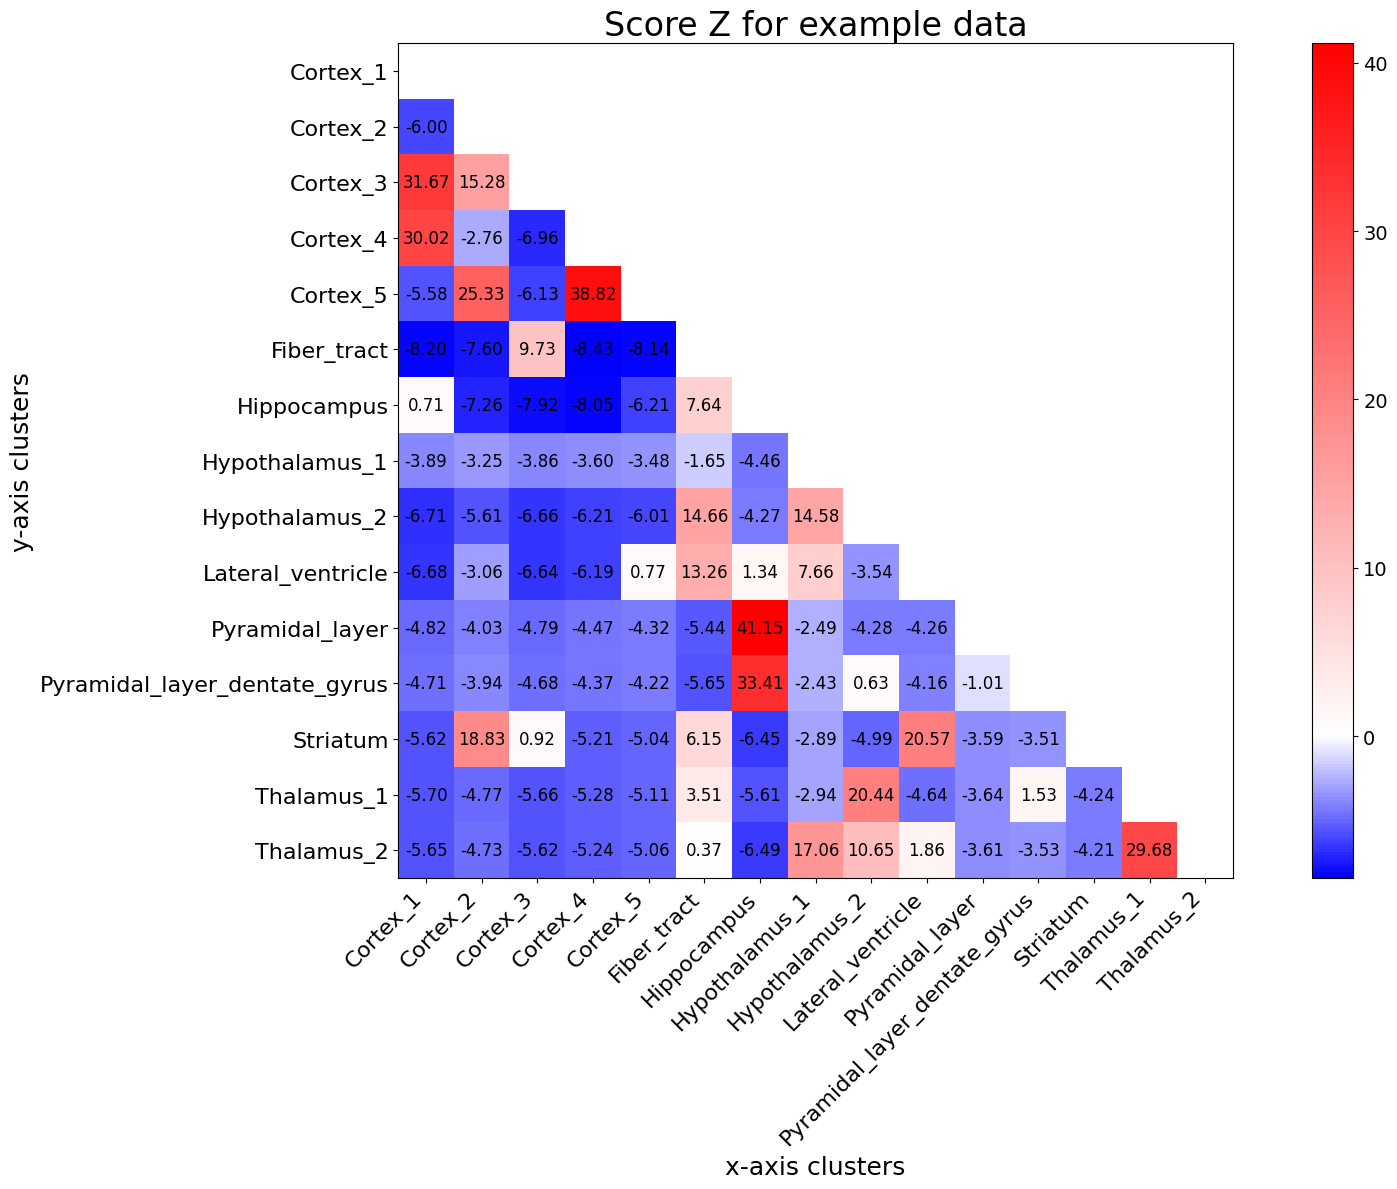

,Cortex_1,Cortex_2,Cortex_3,Cortex_4,Cortex_5,Fiber_tract,Hippocampus,Hypothalamus_1,Hypothalamus_2,Lateral_ventricle,Pyramidal_layer,Pyramidal_layer_dentate_gyrus,Striatum,Thalamus_1,Thalamus_2
Cortex_1,0.000000,-6.001364,31.667341,30.016554,-5.576356,-8.200633,0.706459,-3.886326,-6.705850,-6.679076,-4.820076,-4.708580,-5.619295,-5.697919,-5.650871
Cortex_2,-6.001364,0.000000,15.280089,-2.757309,25.329224,-7.597942,-7.257411,-3.253869,-5.607779,-3.057729,-4.034336,-3.941184,18.834638,-4.767300,-4.728038
Cortex_3,31.667341,15.280089,0.000000,-6.962526,-6.127932,9.725591,-7.924944,-3.862013,-6.663564,-6.636962,-4.789856,-4.679067,0.917617,-5.662108,-5.615361
Cortex_4,30.016554,-2.757309,-6.962526,0.000000,38.816777,-8.426579,-8.047658,-3.603518,-6.214347,-6.189577,-4.468630,-4.365351,-5.208752,-5.281543,-5.237986
Cortex_5,-5.576356,25.329224,-6.127932,38.816777,0.000000,-8.143092,-6.209056,-3.484070,-6.006999,0.767455,-4.320240,-4.220425,-5.035467,-5.105801,-5.063715
Fiber_tract,-8.200633,-7.597942,9.725591,-8.426579,-8.143092,0.000000,7.636525,-1.645142,14.656462,13.256713,-5.439155,-5.653609,6.145835,3.509804,0.369816
Hippocampus,0.706459,-7.257411,-7.924944,-8.047658,-6.209056,7.636525,0.000000,-4.457188,-4.269990,1.337737,41.147292,33.408617,-6.449247,-5.611606,-6.485585
Hypothalamus_1,-3.886326,-3.253869,-3.862013,-3.603518,-3.484070,-1.645142,-4.457188,0.000000,14.578076,7.656675,-2.485268,-2.428035,-2.894960,-2.935207,17.058302
Hypothalamus_2,-6.705850,-5.607779,-6.663564,-6.214347,-6.006999,14.656462,-4.269990,14.578076,0.000000,-3.538881,-4.278127,0.628905,-4.986294,20.436627,10.647590
Lateral_ventricle,-6.679076,-3.057729,-6.636962,-6.189577,0.767455,13.256713,1.337737,7.656675,-3.538881,0.000000,-4.261167,-4.162730,20.573484,-4.635962,1.859467


In [ ]:
from spatools.plotting.pl import z_score_matrixplot

st.plz_score_matrixplot(adata, show=True,
              title="Score Z for example data",
              return_object=True
              )

In [14]:
adata.uns["z-score"]["sample"]

,combination,count,proportion_observed,proportion_expected,std_dev,Z_score
0,"(Cortex_1, Cortex_2)",2.0,0.000543,0.010736,0.001698,-6.001364
1,"(Cortex_1, Cortex_3)",290.0,0.078762,0.015106,0.002010,31.667341
2,"(Cortex_1, Cortex_4)",256.0,0.069527,0.013158,0.001878,30.016554
3,"(Cortex_1, Cortex_5)",8.0,0.002173,0.012303,0.001817,-5.576356
4,"(Cortex_1, Fiber_tract)",8.0,0.002173,0.021994,0.002417,-8.200633
...,...,...,...,...,...,...
100,"(Pyramidal_layer_dentate_gyrus, Thalamus_1)",18.0,0.004889,0.003420,0.000962,1.526232
101,"(Pyramidal_layer_dentate_gyrus, Thalamus_2)",0.0,0.000000,0.003364,0.000954,-3.525571
102,"(Striatum, Thalamus_1)",0.0,0.000000,0.004859,0.001146,-4.240003
103,"(Striatum, Thalamus_2)",0.0,0.000000,0.004780,0.001137,-4.205129


In [15]:
adata.uns["check_spots"]

,spots_analysed,total_spots_anndata,percentage
Sample,2688,2688,100.0


# Multi-sample analysis

## 🧬 Overview
### In this analysis I've used a sample from my project in which there are good, bad and partial responders.
## ⚠️ Note:
### The following steps should be repeated for all three categories.

In [16]:
import os
import numpy as np
import scanpy as sc
import pandas as pd
import spatools as st 
import matplotlib as mpl
import matplotlib.pyplot as plt

adata = sc.read(os.path.join("..", "data", "scvi_non_5000_unique.h5ad"))
adata = st.tl.correlate_distances(adata, is_concatenated=True, cluster_col="clusters_0.6", batch_key="batch")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../data/scvi_non_5000_unique.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
type(adata.obsm["spatial"])# spatial data must be like this

In [ ]:
adata.obsm["spatial"]# spatial data must be like this

In [ ]:
adata.uns["spatools"]# output of the previous function

In [ ]:
adata.uns["spatools"]["response"] = adata.uns["spatools"]["batch"].str.split("_").str[1]# this step is not totaly necessary, depends on your biological question

adata = st.tl.z_score(adata, filter_column="response", filter_value="GOR")

In [ ]:
adata.uns_keys()

In [ ]:
st.pl.z_score_matrixplot(adata, show=True,
              title="Score Z das conexões entre os maus respondedores",
              )

In [ ]:
samples = adata.uns["zscore_matrix"].keys()

for sample in samples:
    print(sample)

In [ ]:
st.pl.boxplot_cluster_correlations(adata, cluster_col="clusters_0.6", 
                             show=True, 
                             title="Colocalization scores in good responders",
                             subset=True,
                             value=9,
                             figsize=(8, 12),
                             title_font=40,
                             label_font= 25,
                             ticks_font=20
                             )

In [ ]:
adata.uns["stats"]